# Notebook Explanation: Testing a Conventional Baseline Under Biased Business Data

This notebook tests the failure mode described in the P34 / PARML paper: a conventional model can look strong when evaluated only on historically observed business trades, yet fail when deployed against the full opportunity menu.

The core issue is selection bias. In real business data, the company usually knows reliable outcomes only for the actions it actually took, or for safely grounded variants of those actions. It does not observe clean labels for every opportunity it could have taken. Therefore, the historical dataset is not a random sample of the market. It is the result of a prior business policy that already tried to select good trades.

This notebook creates a synthetic market where that problem is visible and measurable. It then trains an industry-style baseline model on the business-observed data and compares two evaluations:

1. **Naive business-observed evaluation**: score only the kinds of trades the business historically observed.
2. **Deploy-time simulation**: score the full future opportunity menu, including opportunities that were not historically observed.

The expected behavior is that the naive evaluation looks profitable, while the deploy-time simulation exposes hidden false positives.


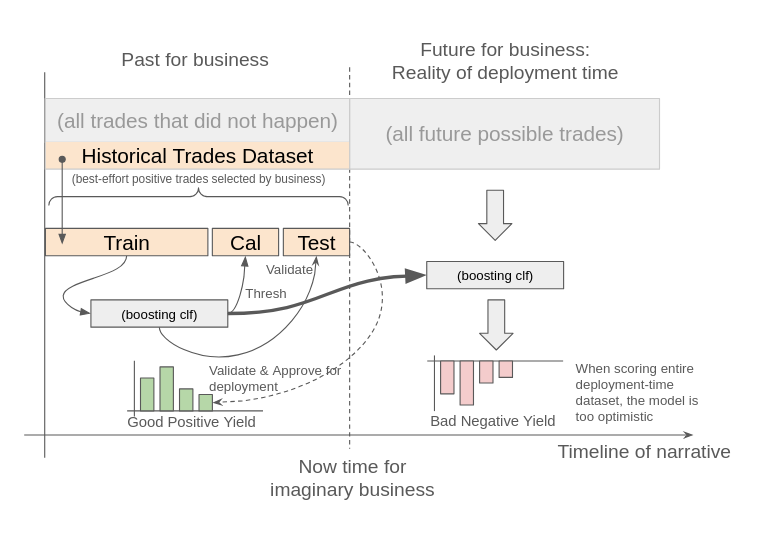

In [1]:
from IPython.display import Image, display
display(Image(filename="problem_statement.png"))

<div style="font-size: 18px;">
Imports
</div>

In [2]:
# run from the repository parent or the repository itself
import os
if os.path.basename(os.getcwd()) != "p34-technical-report":
    os.chdir("p34-technical-report")

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme(style="whitegrid")
from IPython.display import display

from market_synth import (
    ModernMarketSynthConfig,
    convert_market_dataset_state,
    get_market_dataset,
    save_market_dataset,
)

## Market Configuration

This section defines the synthetic market used for the test.

The configuration intentionally creates a market with slower market waves, changing profitability, hidden demand variation, downside regimes, operational costs, and a biased business-selection policy. These settings are designed to reproduce the kind of environment described in the P34 paper: a computable market where actions are measurable, but the true market signal is not directly available as a clean data feed.

Important elements in this configuration:

* `market_observed_period` and `market_latent_period` create slow market cycles.
* `market_profit_trend_strength` creates a profitability trend that can make historical relationships less reliable in the future.
* `downside_regime_*` parameters create hidden downside risk.
* `policy_threshold_*` and `policy_score_noise_scale` define the historical business policy that decides which opportunities become observed.
* `policy_exploration_accept_rate=0.01` means the business accepts a small number of exploratory trades, but most observations still come from a biased selection process.

In the language of the paper, this is not meant to be a perfectly realistic market simulator. It is a controlled testbed for isolating partial observability, biased labels, regime drift, and false-positive risk.


In [4]:
random_state = 42

config = ModernMarketSynthConfig(
    # Market Wave
    market_observed_period=100.0,
    market_latent_period=100.0,
    market_trend_segments=None,

    # Price / Cost / Volume
    cluster_sv_range=(0.01, 3.0),
    lcogs_floor_base=18.0,
    lcogs_floor_amplitude=8.50,
    base_price=34.0,
    lcogs_draw_skew=1,
    volume_amplitude=0.65,
    holding_cost_per_unit=0.5,
    leftover_writeoff_fraction=1,
    market_profit_trend_strength=1.75,

    # Hidden Demand / Downside Risk
    latent_offer_edge_noise_scale=0.18,
    latent_offer_fragility_noise_scale=0.10,
    downside_regime_base_prob=0.01,
    downside_regime_max_prob=0.28,
    downside_regime_best_demand_mult=0.90,
    downside_regime_worst_demand_mult=0.10,
    downside_regime_max_extra_cost_frac=0.55,
    market_latent_amplitude=0.16,
    market_latent_noise_amplitude=0.10,

    # Business Selection Policy
    policy_threshold_base=1.90,
    policy_threshold_amplitude=0.30,
    policy_threshold_noise_amplitude=0.08,
    policy_score_noise_scale=0.75,
    policy_exploration_accept_rate=0.01,
    business_operational_cost_per_unit=2.5,
    mid_sv_threshold=3.0,

    # note: more knobs are available in ModernMarketSynthConfig defaults for full control
)

## Simulate Business Data

This section generates the synthetic market dataset.

The generated data contains both:

* **observed / labeled rows**, representing actions the business historically took or safely grounded; and
* **unobserved / unlabeled rows**, representing options that existed in the market menu but were not chosen by the historical business policy.

This distinction is central to the P34 problem. A normal supervised-learning model usually trains only on the labeled rows. But at deployment time, the model faces a much wider menu of candidate actions. If the labeled rows are biased toward historically selected trades, the model may overestimate profitability when it is exposed to the full menu.

In [5]:
market_dataset = get_market_dataset(
    random_state=random_state,
    config=config,
)

  0%|          | 0/30 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:01<00:29,  1.03s/it]

  7%|▋         | 2/30 [00:02<00:30,  1.10s/it]

 10%|█         | 3/30 [00:03<00:33,  1.24s/it]

 13%|█▎        | 4/30 [00:04<00:32,  1.26s/it]

...

100%|██████████| 30/30 [00:35<00:00,  1.19s/it]

Generated 3931200 telemetry points.


Policy exploration accepts: 180 / 18,068 accepted-by-policy (1.00%) vs target 1.00% [requested picks=180]


Min date in X_test: 80.0
Max date in X_train: 79.0


Min date in X_test: 80.0
Max date in X_train: 79.0


## Data Inspection

This section reconstructs the training and evaluation views needed to inspect the market.

The notebook combines historical observed rows, historical unobserved rows, future observed rows, and future unobserved rows into inspection frames. This allows us to compare what the business historically saw against what the full market actually contained.

The important idea is that the model does not get clean access to the full truth during training. The full market is available here only because this is a synthetic benchmark. That lets us measure the gap between the business-observed sample and the actual deployment-time opportunity set.

<div style="font-size: 18px;">
Prepare data for inspection
</div>

In [6]:
inspection = market_dataset["inspection"]
rng = np.random.default_rng(random_state)

hist_observed = inspection["hist_observed"]
hist_unobserved = inspection["hist_unobserved"]
train_all = inspection["train_all"]
eval_all = inspection["eval_all"]
inspect_all = inspection["inspect_all"]

segment_colors = {"observed": "orange", "unobserved": "darkgray"}
train_eval_boundary_week = float(eval_all["date"].min())

## Business Acceptance Rate by Week

This chart shows how often the historical business policy accepted opportunities over time.

The acceptance rate is not random. It changes with market conditions and with the hidden business policy. This matters because the labeled dataset is created by this policy. When the policy accepts more opportunities, more outcomes become visible. When it rejects opportunities, those outcomes remain unobserved.

This is one of the main reasons ordinary holdout testing can be misleading. If both training and testing are drawn from the same policy-filtered data, the model may appear strong while still failing on the wider deployment menu.


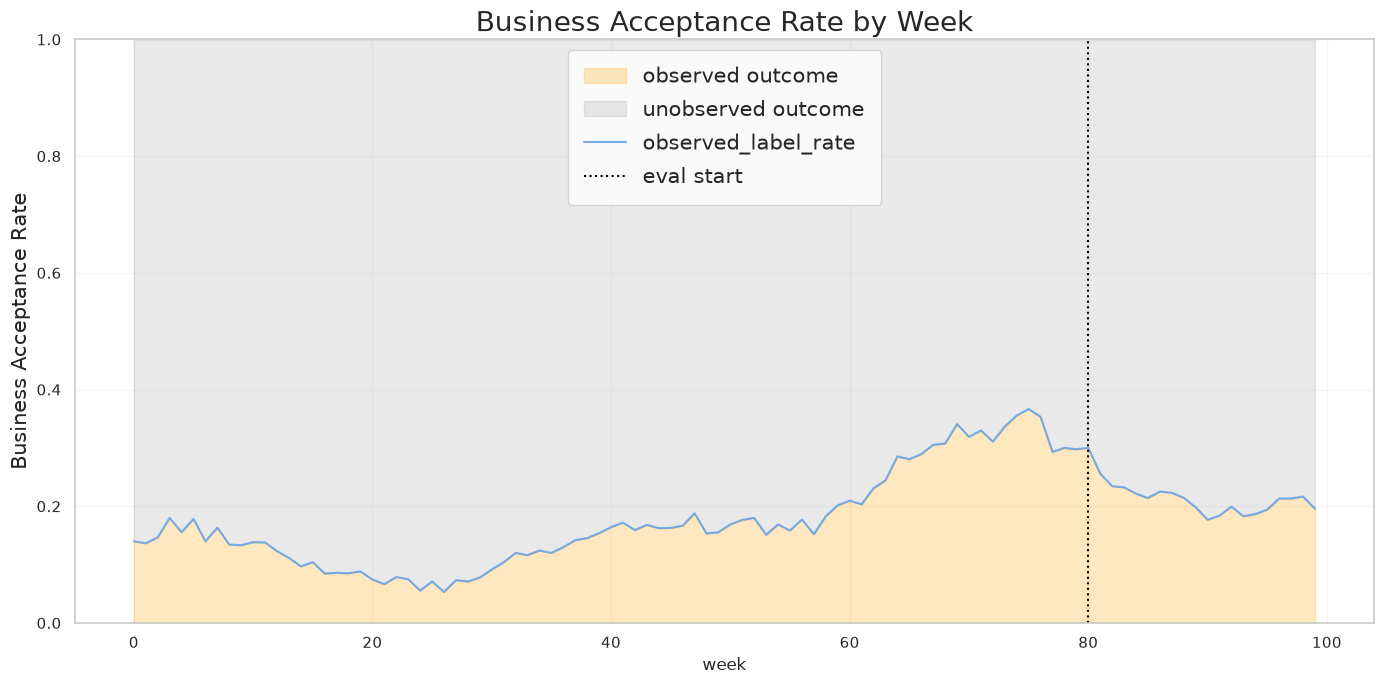

In [7]:
label_rate_by_week = (
    inspect_all[["date", "key", "segment"]]
    .drop_duplicates(["date", "key"])
    .groupby("date")
    .agg(observed_label_rate=("segment", lambda s: (s == "observed").mean()))
    .reset_index()
)
fig, ax = plt.subplots(figsize=(14, 7))

x = label_rate_by_week["date"]
y = label_rate_by_week["observed_label_rate"]
ax.fill_between(x, 0, y, color=segment_colors["observed"], alpha=0.25, label="observed outcome")
ax.fill_between(x, y, 1, color=segment_colors["unobserved"], alpha=0.25, label="unobserved outcome")
ax.plot(x, y, color="#6aa5e7", lw=1.5, alpha=0.9, label="observed_label_rate")
ax.set_title("Business Acceptance Rate by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylim(0, 1)
ax.set_ylabel("Business Acceptance Rate", fontsize=15)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.grid(alpha=0.2)
ax.legend(fontsize=15, frameon=True, borderpad=0.8, labelspacing=0.6)
plt.tight_layout()

## Row Count by Week
This chart counts grounded rows by week, split into observed and unobserved segments.

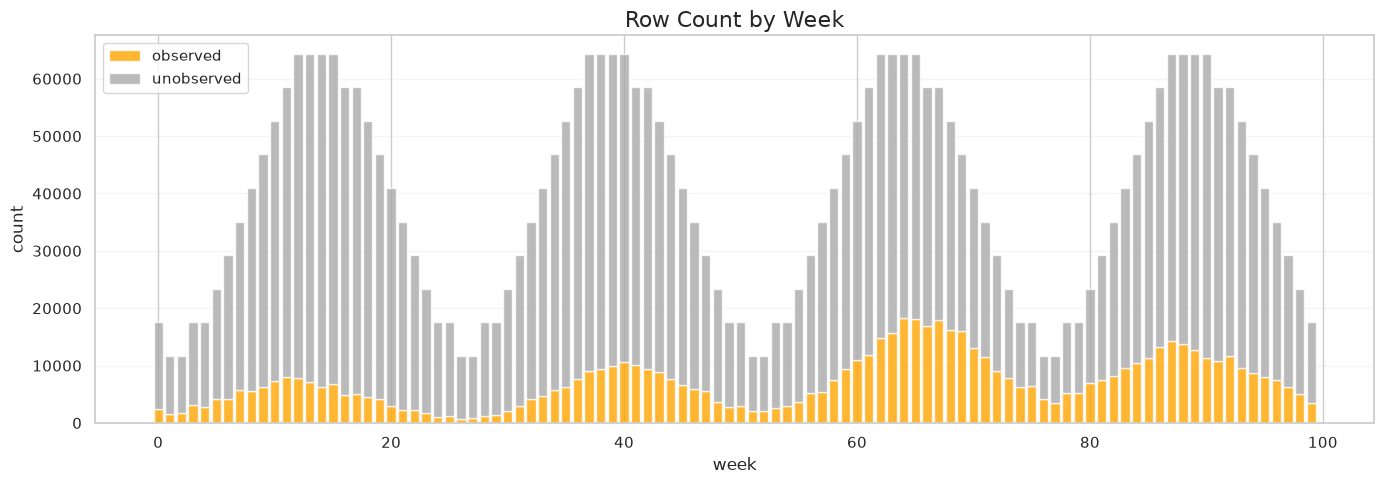

In [8]:
count_by_date = (
    inspect_all
    .groupby(["date", "segment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["observed", "unobserved"], fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    count_by_date.index,
    count_by_date["observed"],
    label="observed",
    color=segment_colors["observed"],
    alpha=0.8,
)
ax.bar(
    count_by_date.index,
    count_by_date["unobserved"],
    bottom=count_by_date["observed"],
    label="unobserved",
    color=segment_colors["unobserved"],
    alpha=0.8,
)

ax.set_title("Row Count by Week", fontsize=16)
ax.set_xlabel("week")
ax.set_ylabel("count")
ax.grid(alpha=0.2, axis="y")
ax.legend()
plt.tight_layout()

## Profit Distribution

This section compares profit distributions for observed and unobserved rows.

The key diagnostic is whether observed rows and unobserved rows have different profit distributions. If they do, the historical business data is biased. A model trained only on observed rows is not learning from the full market distribution. It is learning from the subset that the business policy allowed it to see.

This reproduces the paper's central real-world problem: businesses usually observe the outcomes of selected actions, not the outcomes of all available actions.


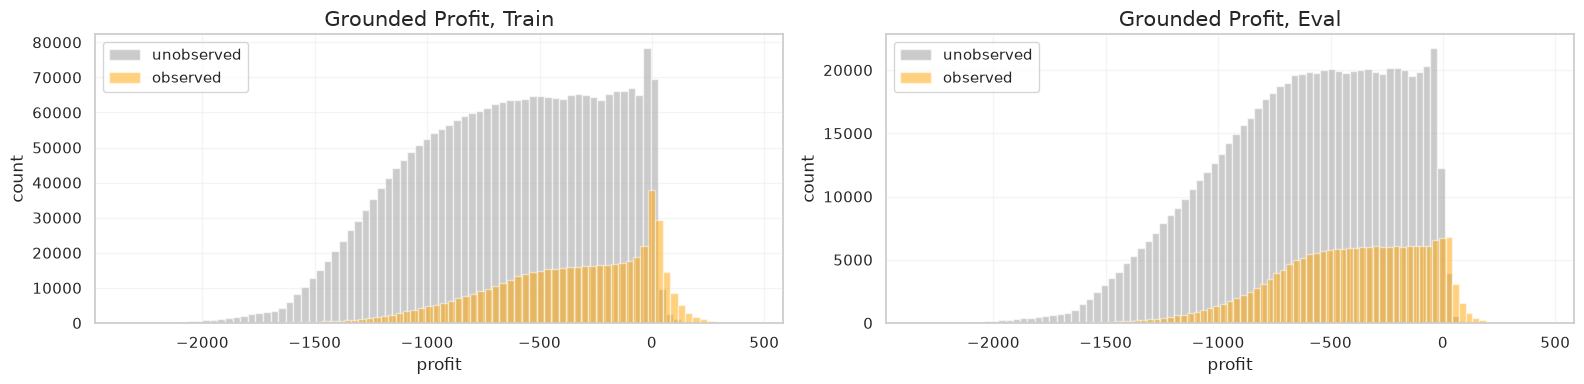

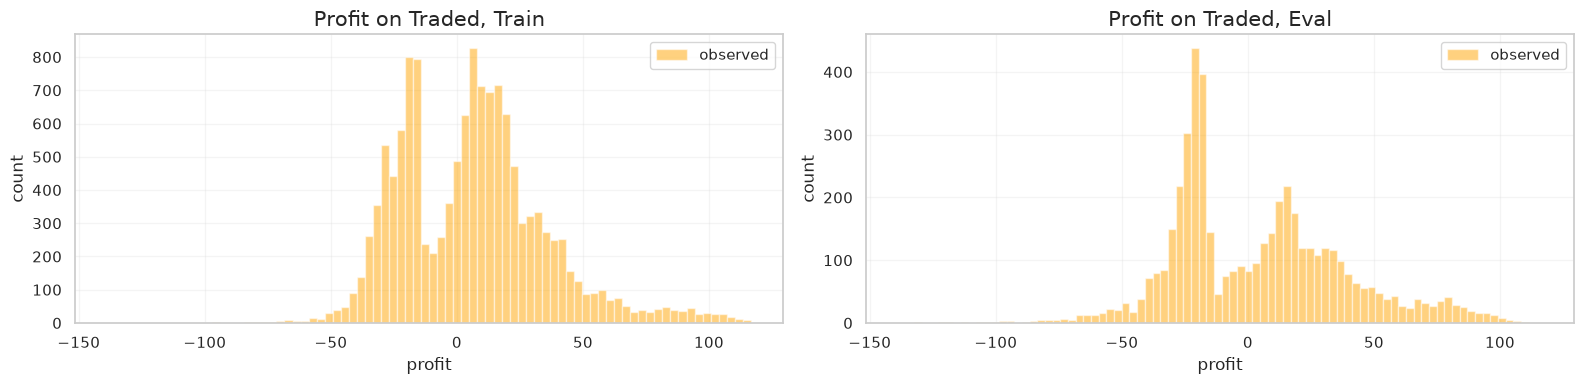

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, df, title in [
    (axes[0], train_all, "Grounded Profit, Train"),
    (axes[1], eval_all, "Grounded Profit, Eval"),
]:
    ax.hist(df.loc[df["segment"] == "unobserved", "profit"], bins=80, alpha=0.6, label="unobserved", color=segment_colors["unobserved"])
    ax.hist(df.loc[df["segment"] == "observed", "profit"], bins=80, alpha=0.5, label="observed", color=segment_colors["observed"])
    ax.set(xlabel="profit", ylabel="count")
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, df, title in [
    (axes[0], train_all[train_all["is_business_chosen_qty"] & train_all["segment"].eq("observed")], "Profit on Traded, Train"),
    (axes[1], eval_all[eval_all["is_business_chosen_qty"] & eval_all["segment"].eq("observed")], "Profit on Traded, Eval"),
]:
    ax.hist(df["profit"], bins=80, alpha=0.5, label="observed", color=segment_colors["observed"])
    ax.set(xlabel="profit", ylabel="count")
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

## Profit by Week

This chart shows how average profit changes over time for business-traded observed rows.

The purpose is to inspect market drift. If profitability changes across weeks, then a model trained on past observed trades may not generalize to future opportunities. This is especially dangerous when the model is deployed into a broader menu than the one represented in the training data.

In the paper's terminology, this is the interaction between selection bias and regime change. The model can learn a historical pattern that was true for prior accepted trades but becomes unsafe under future market conditions.


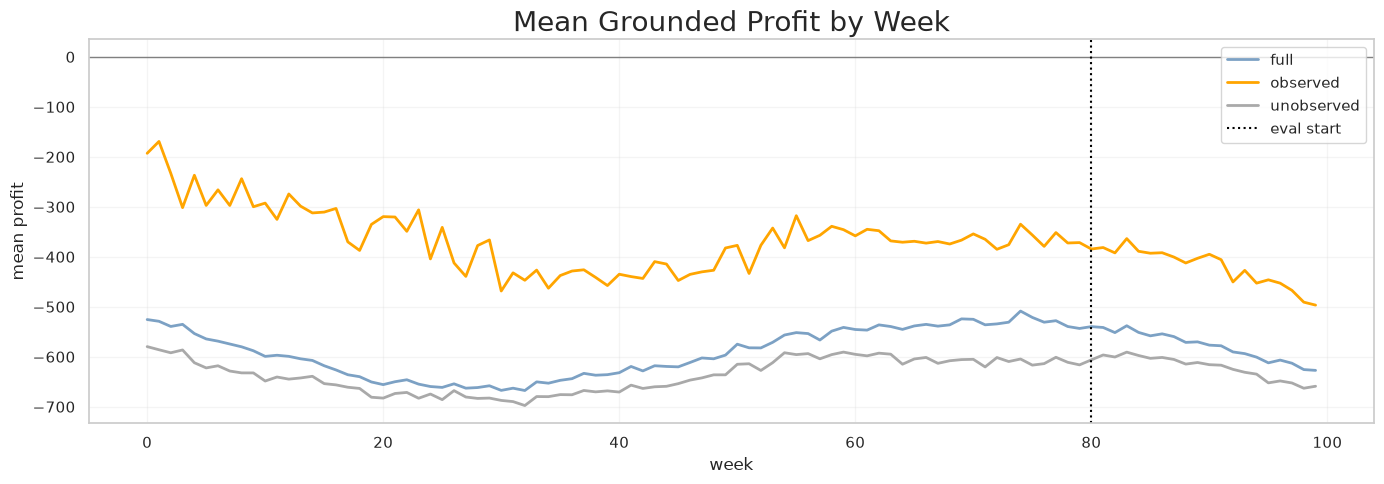

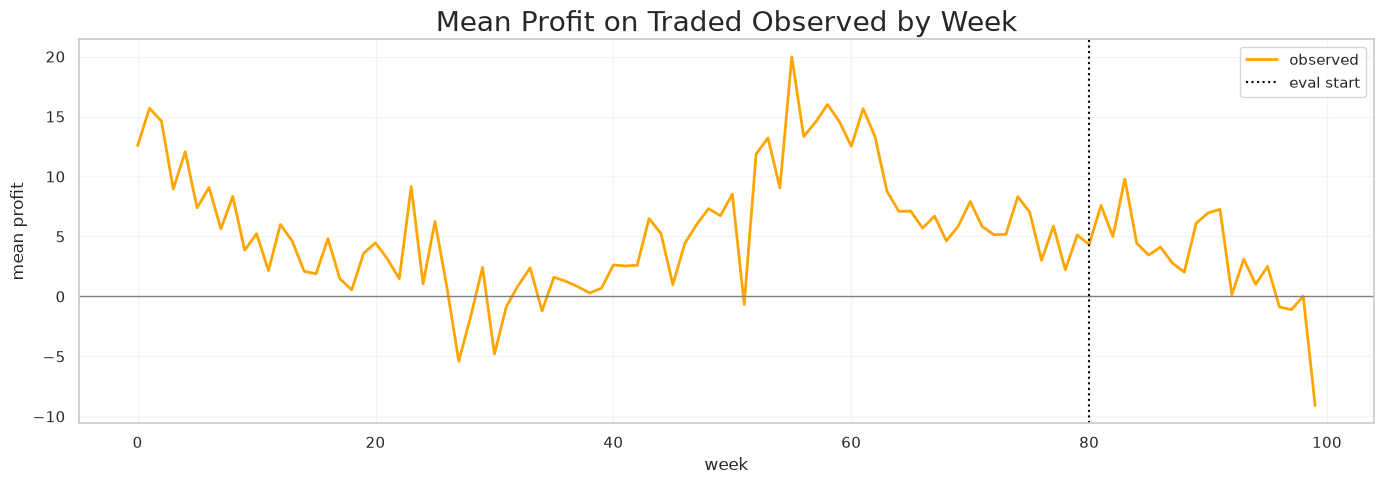

In [10]:
profit_by_week = {}
for name, df in [("grounded", inspect_all), ("traded", inspect_all[inspect_all["is_business_chosen_qty"]])]:
    profit_by_week[name] = (
        df.groupby("date")["profit"].mean().rename("full").to_frame()
        .join(df.groupby(["date", "segment"])["profit"].mean().unstack("segment"))
        .reset_index()
    )
grounded_profit_by_week = profit_by_week["grounded"]
traded_profit_by_week = profit_by_week["traded"]

grounded_plot = grounded_profit_by_week.copy()
grounded_cols = ["full", "observed", "unobserved"]
grounded_colors = {"full": "#7CA1C4", **segment_colors}

fig, ax = plt.subplots(figsize=(14, 5))
for col in grounded_cols:
    ax.plot(grounded_plot["date"], grounded_plot[col], lw=2, label=col, color=grounded_colors[col])

ax.axhline(0, c="gray", lw=1)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.set_title("Mean Grounded Profit by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

profit_by_week = traded_profit_by_week
col = "observed"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(profit_by_week["date"], profit_by_week[col], lw=2, label=col, color=segment_colors[col])

ax.axhline(0, c="gray", lw=1)
ax.axvline(train_eval_boundary_week, color="black", ls=":", lw=1.5, label="eval start")
ax.set_title("Mean Profit on Traded Observed by Week", fontsize=20)
ax.set_xlabel("week")
ax.set_ylabel("mean profit")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

<div style="font-size: 18px;">
Features
</div>

In [11]:
baseline_feature_cols = ["lcogs", "qty", "sv", "isv"]
observed_baseline_features = hist_observed[baseline_feature_cols]
display(observed_baseline_features.describe().round(2))

,lcogs,qty,sv,isv
count,521313.00,521313.00,521313.00,521313.00
mean,23.47,20.00,1.74,8.36
std,7.22,11.25,1.66,21.95
min,9.50,1.00,0.01,0.23
25%,17.25,10.00,0.25,0.24
50%,24.35,20.00,1.06,0.94
75%,28.87,30.00,4.22,3.97
max,37.97,39.00,4.36,152.82


## Policy Score

Policy Score represents a score the business historically used to decide whether to accept an opportunity.

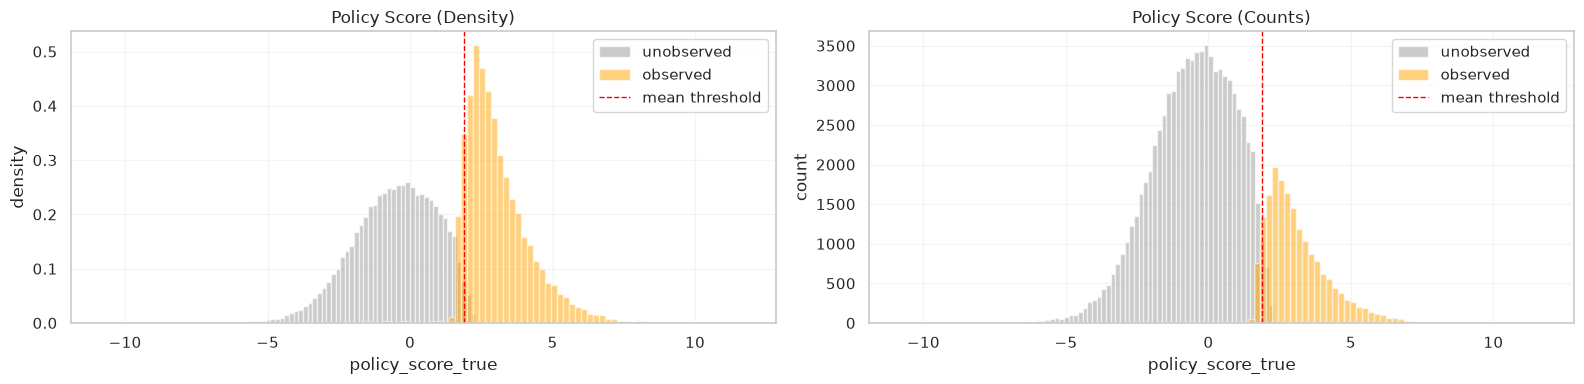

In [12]:
policy_df = inspection["key_policy_df"]
score_threshold = float(policy_df["policy_threshold_t"].mean())
observed_scores = policy_df.loc[policy_df["accepted"], "policy_score_true"]
unobserved_scores = policy_df.loc[~policy_df["accepted"], "policy_score_true"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for ax, density, ylabel, title in [
    (axes[0], True, "density", "Policy Score (Density)"),
    (axes[1], False, "count", "Policy Score (Counts)"),
]:
    ax.hist(unobserved_scores, bins=80, alpha=0.6, label="unobserved", density=density, color=segment_colors["unobserved"])
    ax.hist(observed_scores, bins=80, alpha=0.5, label="observed", density=density, color=segment_colors["observed"])
    ax.axvline(score_threshold, color="red", ls="--", lw=1, label="mean threshold")
    ax.set(title=title, xlabel="policy_score_true", ylabel=ylabel)
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()

## Profit Sensitivity to Quantity

This section plots profit curves by quantity for sampled keys.

The curves show why quantity must be treated as part of the action space. Profit is often non-monotonic: buying more units may improve gross profit at first, then create losses because of excess inventory, writeoffs, holding costs, or demand limits.

This connects directly to the paper's boundary-aware sizing argument. A trading decision is not only "buy or do not buy." It is also "how much should be bought?" A correct model must evaluate trade selection and sizing together.


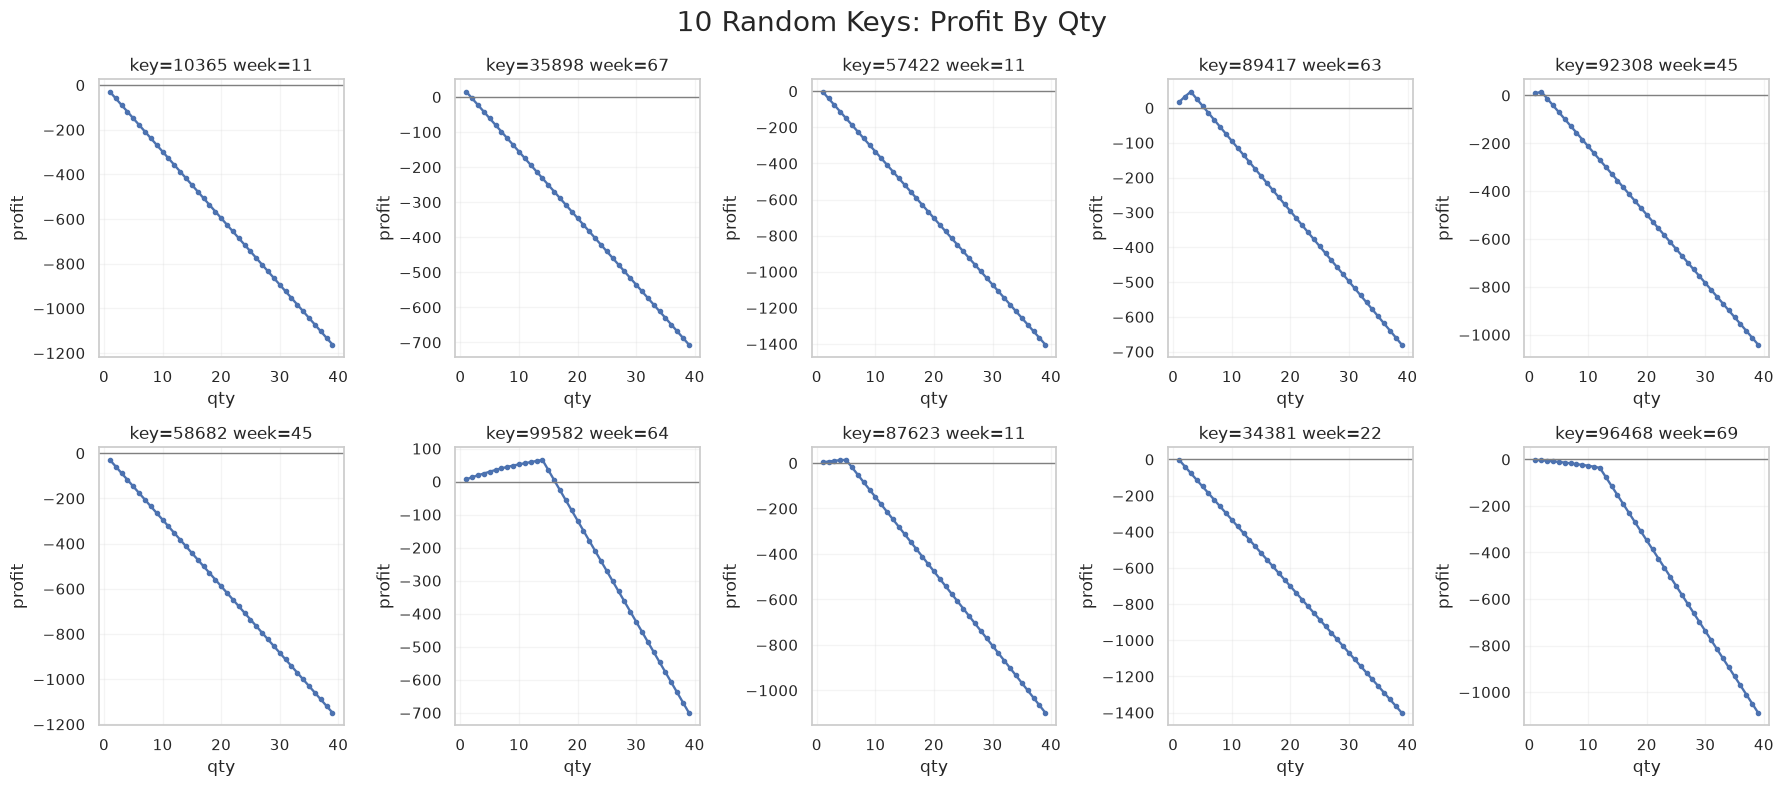

In [13]:
curve_df = train_all[train_all["segment"] == "observed"].copy()
keys_any = rng.choice(curve_df["key"].drop_duplicates(), size=min(10, curve_df["key"].nunique()), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8), squeeze=False)
for ax, key in zip(axes.ravel(), keys_any):
    key_df = curve_df[curve_df["key"] == key].sort_values("qty")
    ax.plot(key_df["qty"], key_df["profit"], marker="o", ms=3, lw=1.7)
    ax.axhline(0, c="gray", lw=1)
    ax.set_title(f"key={int(key)} week={int(key_df['date'].iloc[0])}")
    ax.set_xlabel("qty")
    ax.set_ylabel("profit")
    ax.grid(alpha=0.2)
for ax in axes.ravel()[len(keys_any):]:
    ax.axis("off")
fig.suptitle("10 Random Keys: Profit By Qty", fontsize=20)
plt.tight_layout()

## Current Internal Drivers

These plots show the hidden time-varying market and policy drivers used by the simulator.

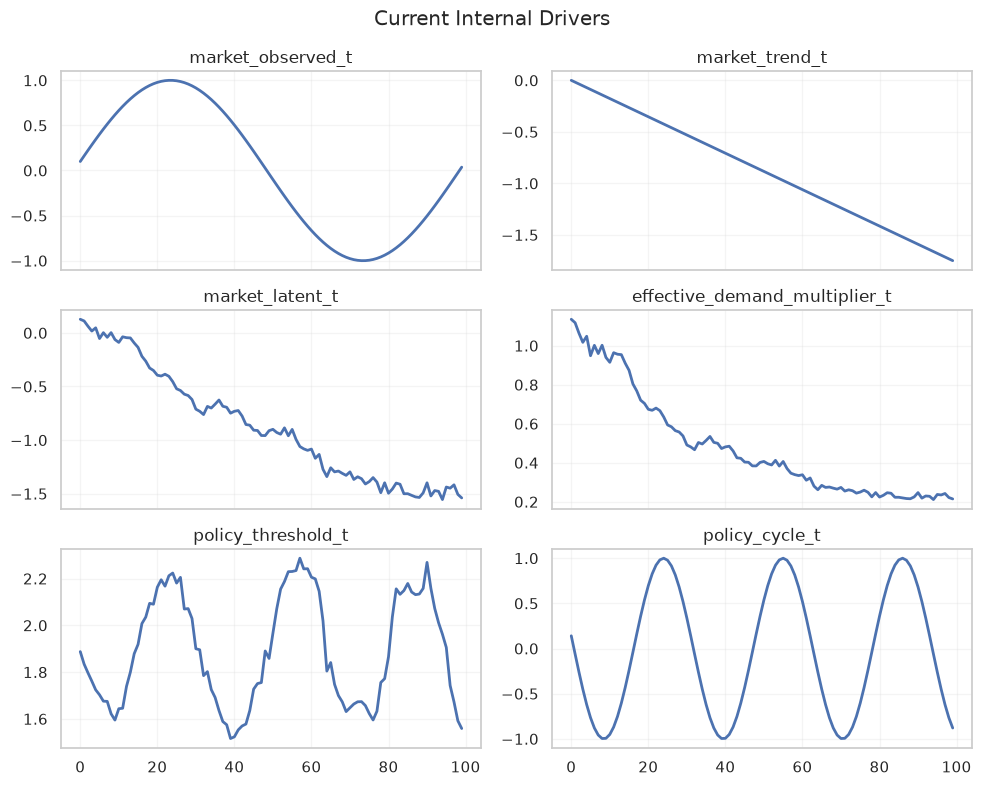

In [14]:
driver_df = inspection["date_process_df"]
driver_cols = [
    "market_observed_t",
    "market_trend_t",
    "market_latent_t",
    "effective_demand_multiplier_t",
    "policy_threshold_t",
    "policy_cycle_t",
]

fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for ax, col in zip(axes.ravel(), driver_cols):
    ax.plot(driver_df["date"], driver_df[col], lw=2)
    ax.set_title(col)
    ax.grid(alpha=0.2)

fig.suptitle("Current Internal Drivers")
plt.tight_layout()

## Reducing Dataset to Business-Traded

This section converts the full synthetic market into the historical view that the business would actually have observed.

This is the key step that creates the realistic training limitation. The model is not trained on the full market. It is trained on business-observed data, meaning the rows that were selected or safely grounded by the historical business process.

In the paper's terms, this creates the biased historical business menu. The unobserved market still exists, but the model does not receive full labels for it.

In [15]:
business_observed_dataset = convert_market_dataset_state(
    market_dataset,
    to_state="historical",
)

## Industry Baseline

This section trains a conventional XGBoost classifier on business-observed data.

The target is whether realized profit is positive. The model is trained only on observed historical rows, using chronological splits for fitting, early stopping, and calibration.

This baseline represents what a capable business data-science team might build with standard tabular ML: train a strong model on historical labeled trades, predict which future trades are likely to be profitable, and select the best candidates.

The model should reach strong validation performance if the conventional baseline is learning signal inside the business-observed data. That means the later failure is more informative: the problem is not simply low model quality, but biased training data and deployment-time distribution mismatch.

In [16]:
BASELINE_EARLY_STOP_FRACTION = 0.20
BASELINE_CALIBRATION_FRACTION = 0.20
BASELINE_NAIVE_EVAL_FRACTION = 0.20
BASELINE_FEATURE_COLS = ["lcogs", "qty", "sv", "isv"]
import shutil
XGB_DEVICE = "cuda" if shutil.which("nvidia-smi") else "cpu"

frames = business_observed_dataset["frames"]
X = frames["X_labeled.parquet"].reset_index(drop=True)
y = frames["y_labeled.parquet"]["profit"].reset_index(drop=True).astype(float)
weeks = frames["x_labeled_dates.parquet"]["date"].reset_index(drop=True)
keys = frames["x_labeled_keys.parquet"]["key"].reset_index(drop=True)
missing_baseline_features = sorted(set(BASELINE_FEATURE_COLS) - set(X.columns))
baseline_feature_cols = BASELINE_FEATURE_COLS

# Train on business-observed rows only
business_observed_frame = X.copy()
business_observed_frame["profit"] = y
business_observed_frame["date"] = weeks
business_observed_frame["key"] = keys


# Keep naive evaluation before deploy-time eval, at the expense of sharing the
# early-stop and threshold-calibration holdout.
unique_weeks = sorted(weeks.unique())
n_early_stop_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_EARLY_STOP_FRACTION)))
n_calibration_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_CALIBRATION_FRACTION)))
n_naive_eval_weeks = max(1, int(np.ceil(len(unique_weeks) * BASELINE_NAIVE_EVAL_FRACTION)))
assert n_early_stop_weeks == n_calibration_weeks
assert n_early_stop_weeks + n_naive_eval_weeks < len(unique_weeks)
naive_eval_weeks = unique_weeks[-n_naive_eval_weeks:]
early_stop_weeks = unique_weeks[-(n_early_stop_weeks + n_naive_eval_weeks):-n_naive_eval_weeks]
calibration_weeks = early_stop_weeks
business_early_stop_mask = business_observed_frame["date"].isin(early_stop_weeks)
business_calibration_mask = business_observed_frame["date"].isin(calibration_weeks)
business_naive_eval_mask = business_observed_frame["date"].isin(naive_eval_weeks)
business_train_mask = ~(business_early_stop_mask | business_naive_eval_mask)
assert not (business_train_mask & business_early_stop_mask).any()
assert (business_early_stop_mask == business_calibration_mask).all()
assert not (business_train_mask & business_naive_eval_mask).any()
assert not (business_early_stop_mask & business_naive_eval_mask).any()

X_business_fit = business_observed_frame.loc[business_train_mask, baseline_feature_cols].astype("float32")
y_business_fit = business_observed_frame.loc[business_train_mask, "profit"]
X_business_early_stop = business_observed_frame.loc[business_early_stop_mask, baseline_feature_cols].astype("float32")
y_business_early_stop = business_observed_frame.loc[business_early_stop_mask, "profit"]
X_business_calibration = business_observed_frame.loc[business_calibration_mask, baseline_feature_cols].astype("float32")
X_business_naive_eval = business_observed_frame.loc[business_naive_eval_mask, baseline_feature_cols].astype("float32")

y_business_fit_binary = (y_business_fit > 0).astype(int)
y_business_early_stop_binary = (y_business_early_stop > 0).astype(int)

fit_pos = int(y_business_fit_binary.sum())
fit_neg = int(len(y_business_fit_binary) - fit_pos)
scale_pos_weight = max(1.0, fit_neg / max(1, fit_pos))
print(
    f"fit rows={len(X_business_fit):,}; early-stop rows={len(X_business_early_stop):,}; "
    f"calibration rows={len(X_business_calibration):,}; "
    f"naive-eval rows={len(X_business_naive_eval):,}; scale_pos_weight={scale_pos_weight:,.2f}"
)


# Define the XGBoost classifier setup
xgb_classifier_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=20000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    random_state=random_state,
    n_jobs=-1,
    device=XGB_DEVICE,
    early_stopping_rounds=150,
)
xgb_classifier_baseline.fit(
    X_business_fit,
    y_business_fit_binary,
    eval_set=[(X_business_fit, y_business_fit_binary), (X_business_early_stop, y_business_early_stop_binary)],
    verbose=100,
)

print(f"best iteration={xgb_classifier_baseline.best_iteration:,}; early-stop AUC={xgb_classifier_baseline.best_score:,.4f}")

fit rows=6,202; early-stop rows=2,660; calibration rows=2,660; naive-eval rows=4,505; scale_pos_weight=1.00


[0]	validation_0-auc:0.72955	validation_1-auc:0.81428


[100]	validation_0-auc:0.95186	validation_1-auc:0.91909


[200]	validation_0-auc:0.95745	validation_1-auc:0.92228


[300]	validation_0-auc:0.95922	validation_1-auc:0.92482


[400]	validation_0-auc:0.95996	validation_1-auc:0.92610


[500]	validation_0-auc:0.96055	validation_1-auc:0.92610


[600]	validation_0-auc:0.96109	validation_1-auc:0.92633


[613]	validation_0-auc:0.96119	validation_1-auc:0.92630


best iteration=463; early-stop AUC=0.9266


In [17]:
# Metrics + predictions on the chronological early-stop holdout
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

y_true = y_business_early_stop_binary.to_numpy()
y_proba = xgb_classifier_baseline.predict_proba(X_business_early_stop)[:, 1]

roc_auc = roc_auc_score(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)
brier = brier_score_loss(y_true, y_proba)

print(f"Early-stop ROC-AUC: {roc_auc:.4f}")
print(f"Early-stop PR-AUC:  {pr_auc:.4f}")
print(f"Early-stop Brier:   {brier:.4f}")

Early-stop ROC-AUC: 0.9266
Early-stop PR-AUC:  0.9467
Early-stop Brier:   0.1003


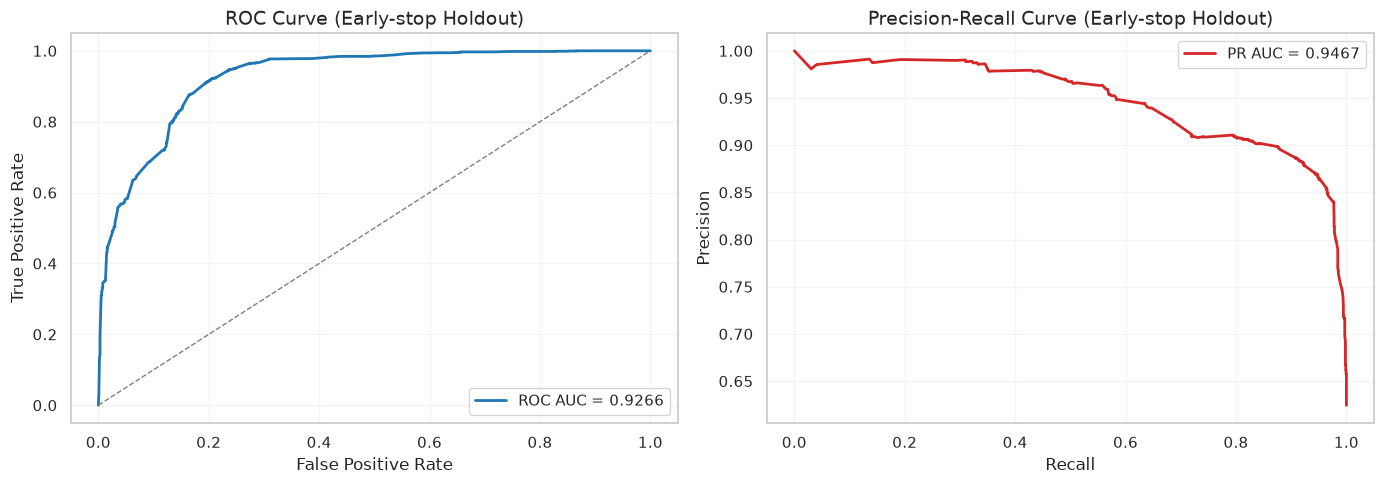

In [18]:
# AUC plots: ROC and Precision-Recall
fpr, tpr, _ = roc_curve(y_true, y_proba)
precision, recall, _ = precision_recall_curve(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, lw=2, color="#1f77b4", label=f"ROC AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[0].set_title("ROC Curve (Early-stop Holdout)", fontsize=14)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(recall, precision, lw=2, color="#d62728", label=f"PR AUC = {pr_auc:.4f}")
axes[1].set_title("Precision-Recall Curve (Early-stop Holdout)", fontsize=14)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()

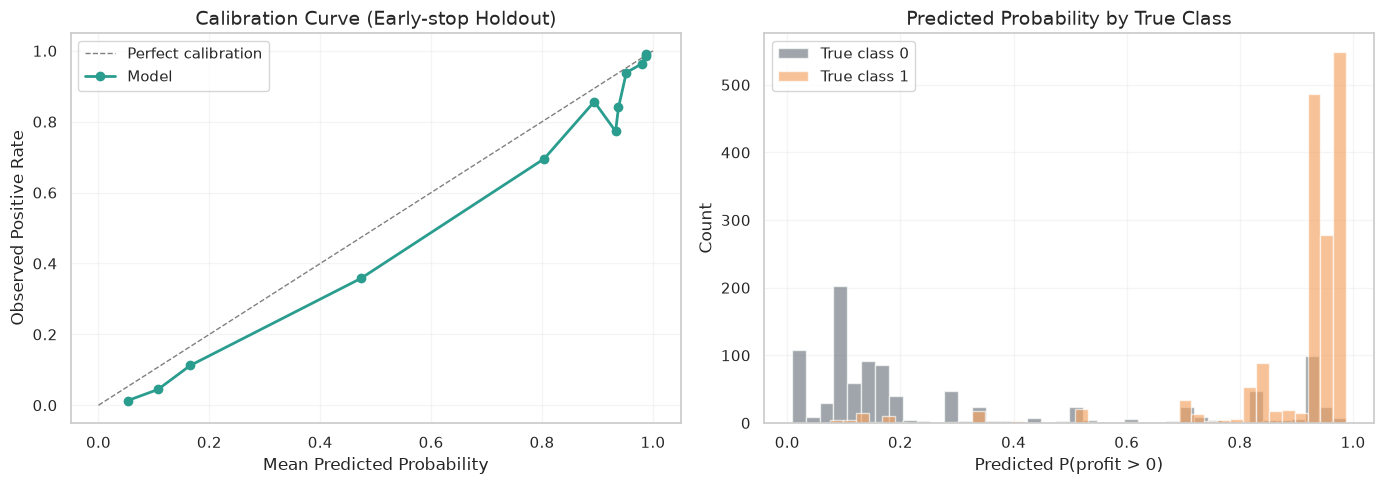

In [19]:
# Calibration plot (reliability diagram + score histogram)
frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=12, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Perfect calibration")
axes[0].plot(mean_pred, frac_pos, marker="o", lw=2, color="#2a9d8f", label="Model")
axes[0].set_title("Calibration Curve (Early-stop Holdout)", fontsize=14)
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Observed Positive Rate")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].hist(y_proba[y_true == 0], bins=40, alpha=0.65, label="True class 0", color="#6c757d")
axes[1].hist(y_proba[y_true == 1], bins=40, alpha=0.65, label="True class 1", color="#f4a261")
axes[1].set_title("Predicted Probability by True Class", fontsize=14)
axes[1].set_xlabel("Predicted P(profit > 0)")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()

## Calibrate the Classifier Threshold

This section calibrates the probability threshold used to decide whether the model should trade.

Instead of using a default threshold like `0.5`, the notebook scans thresholds on a held-out calibration period and chooses the cutoff that maximizes realized profit on selected rows.

This makes the baseline stronger and more realistic. The deploy-time failure cannot be dismissed as a bad threshold choice. The threshold was tuned on historical business-observed data, but that data still does not represent the full future deployment menu.

In [20]:
business_calibration_frame = business_observed_frame.loc[business_calibration_mask, ["date", "key", "profit"]].reset_index(drop=True)
business_calibration_frame["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(X_business_calibration)[:, 1]

calibration_best_per_key = (
    business_calibration_frame
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
threshold_scan = (
    calibration_best_per_key
    .groupby("positive_profit_proba", dropna=False)
    .agg(profit=("profit", "sum"), keys=("key", "nunique"))
    .sort_index(ascending=False)
    .reset_index()
)
threshold_scan["selected_keys"] = threshold_scan["keys"].cumsum()
threshold_scan["profit_on_selected"] = threshold_scan["profit"].cumsum()
threshold_scan = pd.concat([
    pd.DataFrame({
        "positive_profit_proba": [np.nextafter(threshold_scan["positive_profit_proba"].max(), np.inf)],
        "profit": [0.0],
        "keys": [0],
        "selected_keys": [0],
        "profit_on_selected": [0.0],
    }),
    threshold_scan,
], ignore_index=True)
best_threshold_row = threshold_scan.sort_values(["profit_on_selected", "selected_keys"], ascending=[False, True]).iloc[0]
classifier_profit_threshold = (
    np.nextafter(calibration_best_per_key["positive_profit_proba"].max(), np.inf)
    if best_threshold_row["selected_keys"] == 0
    else np.nextafter(best_threshold_row["positive_profit_proba"], -np.inf)
)

print(
    f"calibrated threshold={classifier_profit_threshold:.6f}; "
    f"calibration profit on selected={best_threshold_row['profit_on_selected']:,.2f}"
)

calibrated threshold=0.819396; calibration profit on selected=48,819.96


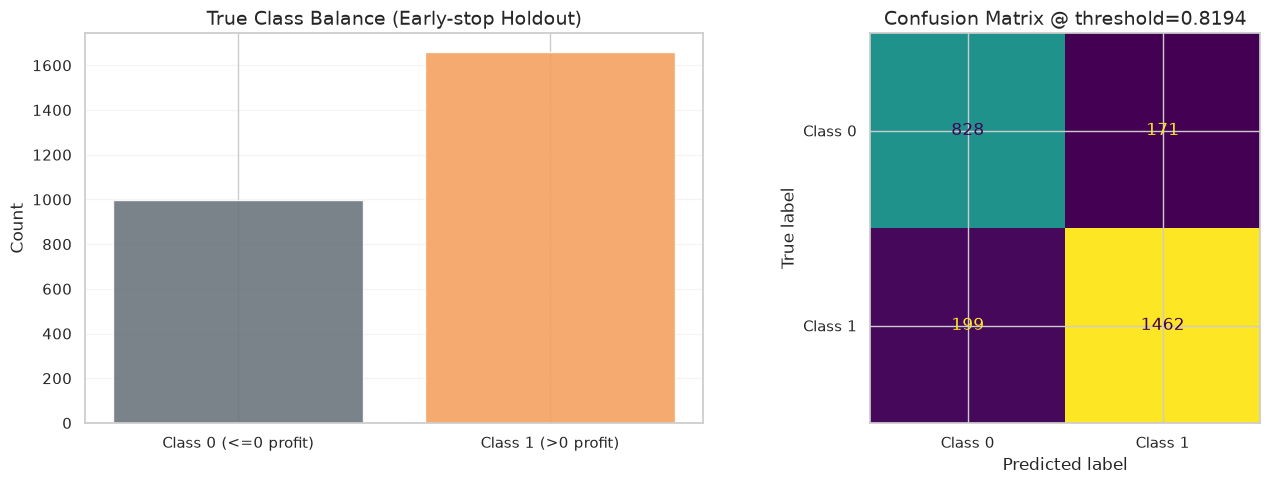

In [21]:
# Class plots: class balance + confusion matrix at your calibrated profit threshold
threshold_for_class_plot = float(classifier_profit_threshold)
y_pred = (y_proba > threshold_for_class_plot).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True class balance
class_counts = pd.Series(y_true).value_counts().sort_index()
axes[0].bar(["Class 0 (<=0 profit)", "Class 1 (>0 profit)"], class_counts.values, color=["#6c757d", "#f4a261"], alpha=0.9)
axes[0].set_title("True Class Balance (Early-stop Holdout)", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.2, axis="y")

# Confusion matrix at selected threshold
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix @ threshold={threshold_for_class_plot:.4f}", fontsize=14)

plt.tight_layout()

## Naive Evaluation on Business-Traded

This section evaluates the model on the last historical business-observed block before deploy-time evaluation.

This is the optimistic evaluation. It asks: "If we only score the kind of trades the business historically selected or observed immediately before deployment, does the model make money?"

This looks like a successful model. It selects better than taking everything and better than doing nothing.

But this is not a true deployment test. It is still filtered through the business-observed subset. It does not test the model against the full opportunity menu that would be available at deployment time.

Total actual profit on model-selected: 61,735.36
Total actual profit Take-All: 27,430.54
Total actual profit Take-None: 0.00


,date,actual_profit_on_selected
0,64.0,6657.14
1,65.0,6662.15
2,66.0,5759.25
3,67.0,6618.60
4,68.0,5074.12
5,69.0,5313.67
6,70.0,5279.17
7,71.0,3718.70
8,72.0,3186.56
9,73.0,2589.67


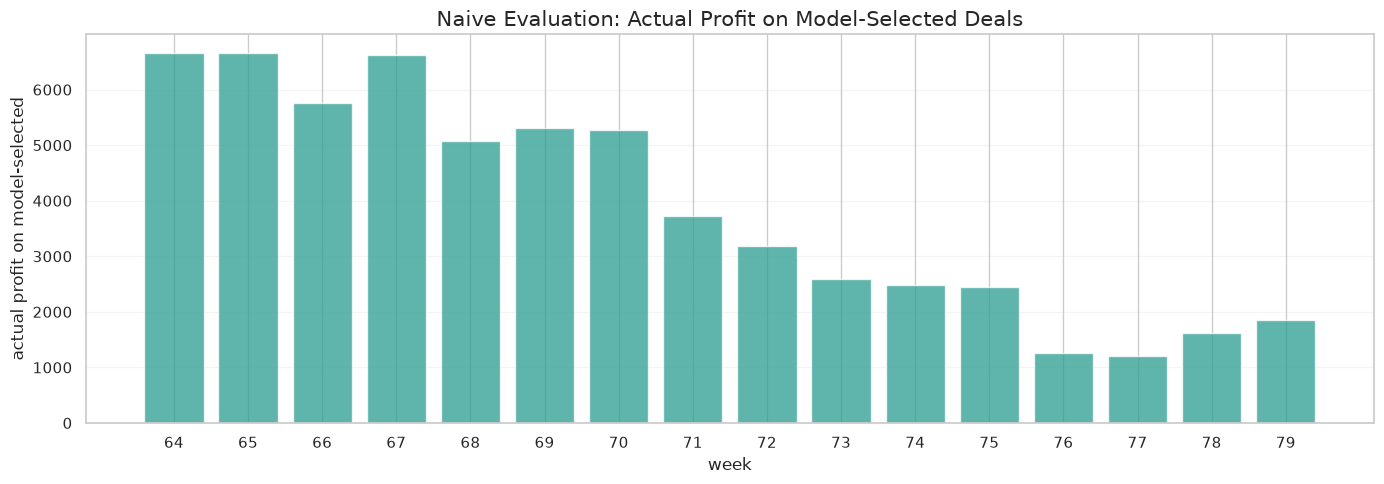

In [22]:
# Naive eval scores only business-observed rows in the historical block
# immediately before deploy-time evaluation.
xgb_classifier_naive_eval = (
    business_observed_frame
    .loc[business_naive_eval_mask, baseline_feature_cols + ["profit", "date", "key"]]
    .reset_index(drop=True)
    .copy()
)
xgb_classifier_naive_eval["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(
    X_business_naive_eval
)[:, 1]

# Apply the calibrated cutoff
xgb_classifier_naive_selected = (
    xgb_classifier_naive_eval[xgb_classifier_naive_eval["positive_profit_proba"] > classifier_profit_threshold]
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
print(f"Total actual profit on model-selected: {xgb_classifier_naive_selected['profit'].sum():,.2f}")
print(f"Total actual profit Take-All: {xgb_classifier_naive_eval['profit'].sum():,.2f}")
print("Total actual profit Take-None: 0.00")

xgb_classifier_naive_by_week = (
    pd.DataFrame({"date": sorted(xgb_classifier_naive_eval["date"].unique())})
    .merge(
        xgb_classifier_naive_selected
        .groupby("date", dropna=False)
        .agg(actual_profit_on_selected=("profit", "sum")),
        on="date",
        how="left",
    )
    .fillna({"actual_profit_on_selected": 0.0})
)
display(xgb_classifier_naive_by_week.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(xgb_classifier_naive_by_week["actual_profit_on_selected"] >= 0, "#2a9d8f", "#d55e00")
ax.bar(
    xgb_classifier_naive_by_week["date"],
    xgb_classifier_naive_by_week["actual_profit_on_selected"],
    color=colors,
    alpha=0.75,
)
ax.axhline(0, c="gray", lw=1)
ax.set_title("Naive Evaluation: Actual Profit on Model-Selected Deals", fontsize=15)
ax.set_xlabel("week")
ax.set_ylabel("actual profit on model-selected")
ax.set_xticks(xgb_classifier_naive_by_week["date"])
ax.set_xticklabels([f"{int(date)}" for date in xgb_classifier_naive_by_week["date"]])
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()

## Deploy-Time Simulation Evaluation

This section performs the more important test.

Instead of scoring only business-observed rows, the model scores the full grounded future evaluation menu: both labeled and unlabeled candidate opportunities. This simulates what happens when the model is deployed and asked to choose from the broader opportunity set.

The same trained classifier and the same calibrated threshold are used. The only major change is the menu being scored.

This is the false-positive collapse. The model looked profitable on the naive business-observed evaluation, but when exposed to the full deployment-time menu, it selected many opportunities that appeared profitable according to the biased historical pattern and were actually negative.

This is exactly the failure mode P34 is designed to address. The lesson is that row-level predictive performance and calibrated thresholds are not enough. The model must reason about biased observation, unobserved alternatives, deployment-time menus, false-positive risk, and portfolio-level economics.

Total actual profit on model-selected: -417,370.54
Total actual profit Take-All: -521,713,014.88
Total actual profit Take-None: 0.00


,date,actual_profit_on_selected
0,80.0,-8788.91
1,81.0,-12867.47
2,82.0,-12832.84
3,83.0,-14940.12
4,84.0,-20409.12
5,85.0,-23520.29
6,86.0,-26814.35
7,87.0,-30470.10
8,88.0,-32246.49
9,89.0,-29197.43


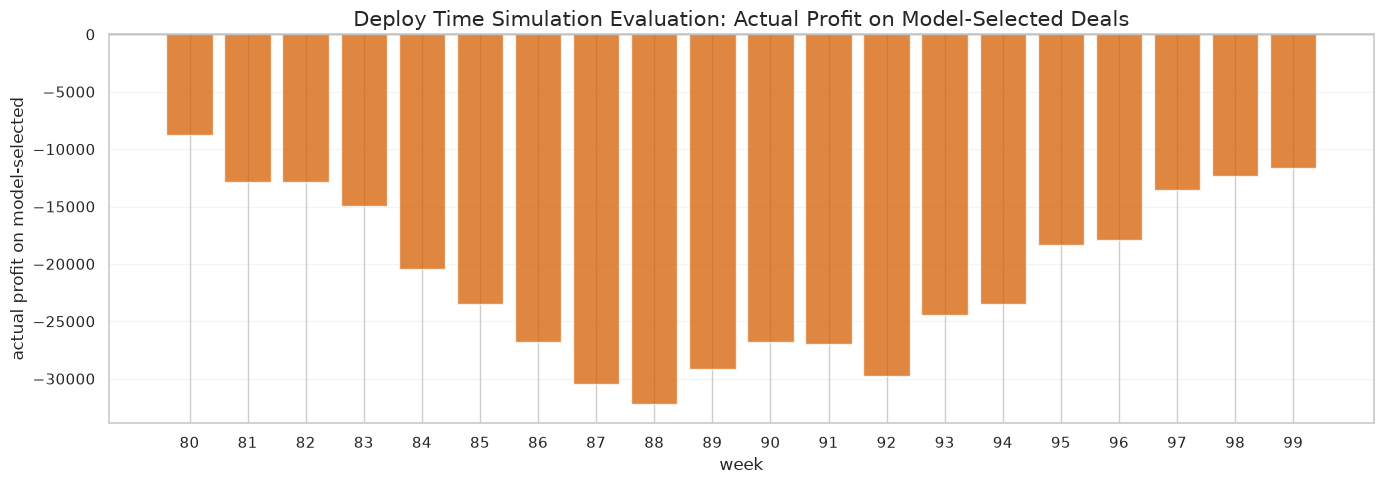

In [23]:
deploy_time_sim_eval = inspection["eval_all"].copy()

# Deploy-time simulation scores the full grounded eval menu
deploy_time_sim_eval["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(
    deploy_time_sim_eval[baseline_feature_cols].astype("float32")
)[:, 1]

# Apply the same cutoff, keep no more than one quantity option row per key
deploy_time_sim_selected = (
    deploy_time_sim_eval[deploy_time_sim_eval["positive_profit_proba"] > classifier_profit_threshold]
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)
print(f"Total actual profit on model-selected: {deploy_time_sim_selected['profit'].sum():,.2f}")
print(f"Total actual profit Take-All: {deploy_time_sim_eval['profit'].sum():,.2f}")
print("Total actual profit Take-None: 0.00")

deploy_time_sim_by_week = (
    pd.DataFrame({"date": sorted(deploy_time_sim_eval["date"].unique())})
    .merge(
        deploy_time_sim_selected.groupby("date", dropna=False).agg(actual_profit_on_selected=("profit", "sum")),
        on="date",
        how="left",
    )
    .fillna({"actual_profit_on_selected": 0.0})
)
display(deploy_time_sim_by_week.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
colors = np.where(deploy_time_sim_by_week["actual_profit_on_selected"] >= 0, "#2a9d8f", "#d55e00")
ax.bar(deploy_time_sim_by_week["date"], deploy_time_sim_by_week["actual_profit_on_selected"], color=colors, alpha=0.75)
ax.axhline(0, c="gray", lw=1)
ax.set_title("Deploy Time Simulation Evaluation: Actual Profit on Model-Selected Deals", fontsize=15)
ax.set_xlabel("week")
ax.set_ylabel("actual profit on model-selected")
ax.set_xticks(deploy_time_sim_by_week["date"])
ax.set_xticklabels([f"{int(date)}" for date in deploy_time_sim_by_week["date"]])
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()

## Interpretation

This notebook demonstrates why the P34 paper argues for Profit-As-Regression Machine Learning rather than ordinary prediction.

A conventional classifier can learn a strong signal inside the historically observed business data. It can pass validation, calibrate well, and make money in a naive holdout test. But if the historical labels are created by a biased prior policy, the model may not understand the unobserved opportunity distribution.

At deployment time, the model is no longer protected by the historical business policy. It sees many more candidates. Some of them resemble profitable historical trades in feature space, but they belong to a different part of the market distribution. These are false positives.

The paper's P34 architecture addresses this by treating the business menu itself as the modeling object. Instead of only asking whether individual rows look profitable, P34 is designed to evaluate candidate portfolios under partial observability, construct plausible interpretations of missing data, account for regime drift, correct false-positive risk, and allow no-trade as a valid decision.

This notebook therefore serves as a clean diagnostic example: it shows why a standard industry baseline can appear successful in a biased historical test while failing in a realistic deploy-time simulation.


# Demo Results of P34 on the Same Market — Live P34 API

The cells below run the **real P34 REST API** on the exact market built above, following the public API documentation:

1. Convert the business-observed history into the documented **Menus** / **Sales** sheets, and pick **one future eval menu** as the reserved `menu = 0` / `T = 0` task the API must decide.
2. `POST /fit` with `menus`, `sales` and `market_type` — the request is validated and grounded, and a `session_id` is returned immediately.
3. Poll `GET /result/{session_id}` until the cluster calculation reaches `done`.
4. Analyze the returned portfolio and reveal the market-synthesis actuals — which the API never saw.

The task menu carries **no outcome values**: the `/fit` contract rejects `profit` on `T = 0` rows, so everything the API learns comes from the biased business-observed history — the same information the baseline classifier had.

Configuration comes from environment variables: `P34_API_URL` (default `https://api.hyperc.com/v1`), `P34_API_KEY` (from the [management console](https://api.hyperc.com/app/), sent as `Authorization: Bearer <key>`), `P34_MODEL` (default `default`), and optional `P34_CONFIDENCE_CORRECTION` in `[-1, 1]` (positive → fewer, higher-confidence selections).

In [24]:
# P34 API configuration and the documented wire helpers.
# Tables travel as base64-encoded Parquet (dtype-exact) or JSON records;
# we use Parquet — the compact option for a history this size.
import base64
import io
import json
import time

import requests

P34_API_URL = os.environ.get("P34_API_URL", "https://api.hyperc.com/v1").rstrip("/")
P34_API_KEY = os.environ.get("P34_API_KEY")  # https://api.hyperc.com/app/ -> API keys
P34_MODEL = os.environ.get("P34_MODEL", "default")
P34_CONFIDENCE_CORRECTION = os.environ.get("P34_CONFIDENCE_CORRECTION")
P34_POLL_SECONDS = int(os.environ.get("P34_POLL_SECONDS", "30"))
P34_TIMEOUT_MINUTES = int(os.environ.get("P34_TIMEOUT_MINUTES", "180"))

p34_api_headers = {"Authorization": f"Bearer {P34_API_KEY}"} if P34_API_KEY else {}


def df_to_b64(df: pd.DataFrame) -> str:
    buf = io.BytesIO()
    df.reset_index(drop=True).to_parquet(buf, index=False)
    return base64.b64encode(buf.getvalue()).decode("ascii")


def b64_to_df(blob: str) -> pd.DataFrame:
    return pd.read_parquet(io.BytesIO(base64.b64decode(blob.encode("ascii"))))


if not P34_API_KEY:
    print("WARNING: P34_API_KEY is not set — POST /fit will be refused (401). "
          "Get a key at https://api.hyperc.com/app/")

service_info = requests.get(f"{P34_API_URL}/", headers=p34_api_headers, timeout=15).json()
print("service:", service_info.get("service"))
print("models: ", service_info.get("models"))
print("using:  ", P34_MODEL, "| API:", P34_API_URL)

service: P34 PARML model API
models:  ['default', 'r003-alpha-ray', 'r008', 'rc012']
using:   default | API: https://api.hyperc.com/v1


## Building the Documented Menus / Sales Sheets

Mapping from this notebook's market to the API's data format:

| API sheet / field | source in this notebook |
| --- | --- |
| Menus `key` | market key (each key exists on exactly one menu) |
| Menus `menu` | market date + 1 for history (`menu = 0` is reserved for the task) |
| Menus `T` | market date − *now*, with *now* anchored one full replay horizon after the last historical offer, so every historical sales window has completed strictly in the past |
| Menus features | `sv`, `isv`, `broken_feature_increasing_noise` — the same observable signals the baseline saw |
| Menus `unit_cost` / `unit_price` | `lcogs` / `price` |
| Menus `historically_chosen` | the quantity the simulated business actually ordered (exactly one row per menu/key) |
| Menus `profit` | realized outcome, on the chosen row only — blank everywhere else, **blank on all task rows** |
| Sales rows | weekly realized sales of each chosen deal, replayed from the simulator's demand paths and rounded to whole units (the API accepts integer sales) |
| Sales `unit_fee` | per-unit extra cost of a key's downside regime, so the service can ground each deal's full economics |
| `market_type` | the same inventory economics the simulator used: replay horizon, holding cost, write-off fraction |

The task menu is one future eval week (sampled reproducibly), covering the **full** deployment menu — the same kind of menu that exposed the baseline's false-positive collapse.

In [25]:
P34_MARKET_TYPE = {
    "market_type": "synthetic_inventory",
    "parameters": {
        "qty_ordered_range": int(config.qty_ordered_range),
        "inventory_holding_weeks_before_writeoff": int(config.weekly_demand_n_weeks),
        "holding_cost_per_unit": float(config.holding_cost_per_unit),
        "leftover_writeoff_fraction": float(config.leftover_writeoff_fraction),
        "grounding_labelling_mode": "synthetic_full",
    },
}


def build_p34_api_sheets(market_dataset, market_type, task_menu_seed=42):
    """Grounded market_synth dataset -> (menus, sales, task_week) API sheets."""
    frames = market_dataset["frames"]
    horizon = int(market_type["parameters"]["inventory_holding_weeks_before_writeoff"])

    X_hist = frames["X_labeled.parquet"].reset_index(drop=True)
    y_hist = frames["y_labeled.parquet"].reset_index(drop=True)
    dates_hist = frames["x_labeled_dates.parquet"].reset_index(drop=True)
    keys_hist = frames["x_labeled_keys.parquet"].reset_index(drop=True)
    meta_hist = frames["metadata/labeled_meta.parquet"].reset_index(drop=True)

    assert (meta_hist["key"].to_numpy() == keys_hist["key"].to_numpy()).all()
    assert (meta_hist["date"].to_numpy() == dates_hist["date"].to_numpy()).all()
    assert np.allclose(meta_hist["qty"].to_numpy(dtype=float), X_hist["qty"].to_numpy(dtype=float))

    feature_cols = [c for c in X_hist.columns if c not in ("lcogs", "price", "qty")]
    chosen = meta_hist["qty"].to_numpy(dtype=float) == meta_hist["business_chosen_qty"].to_numpy(dtype=float)

    # anchor "now" one full replay horizon after the last historical offer
    t_now = float(dates_hist["date"].max()) + horizon

    menus_hist = pd.DataFrame({
        "key": keys_hist["key"].to_numpy(dtype=float),
        "menu": dates_hist["date"].to_numpy(dtype=float) + 1.0,  # menu 0 is reserved
        "T": dates_hist["date"].to_numpy(dtype=float) - t_now,
        "T_lead": 0,
    })
    for col in feature_cols:
        menus_hist[col] = X_hist[col].to_numpy(dtype=float)
    menus_hist["unit_cost"] = X_hist["lcogs"].to_numpy(dtype=float)
    menus_hist["unit_price"] = X_hist["price"].to_numpy(dtype=float)
    menus_hist["qty"] = X_hist["qty"].to_numpy(dtype=float)
    menus_hist["historically_available"] = 1
    menus_hist["historically_chosen"] = chosen.astype(int)
    menus_hist["profit"] = np.where(chosen, y_hist["profit"].to_numpy(dtype=float), np.nan)

    # ---- Sales: weekly realized sales of each chosen deal ----
    chosen_rows = (
        pd.DataFrame({
            "key": menus_hist["key"],
            "menu": menus_hist["menu"],
            "T_menu": menus_hist["T"],
            "qty": menus_hist["qty"],
            "price": menus_hist["unit_price"],
            "lcogs": menus_hist["unit_cost"],
        })[chosen]
        .reset_index(drop=True)
    )
    assert chosen_rows["key"].is_unique  # each key lives on exactly one menu

    demand = frames["metadata/grounding_demand.parquet"]
    demand = demand[demand["key"].isin(chosen_rows["key"])]
    D = (
        demand.pivot(index="key", columns="week_idx", values="demand_units")
        .reindex(chosen_rows["key"])
        .to_numpy(dtype=float)
    )
    assert D.shape == (len(chosen_rows), horizon) and not np.isnan(D).any()

    stock_left = chosen_rows["qty"].to_numpy(dtype=float).copy()
    weekly_sales = np.zeros_like(D)
    for week in range(horizon):
        sold = np.minimum(D[:, week], stock_left)
        weekly_sales[:, week] = sold
        stock_left -= sold

    # the API accepts whole-number sales: round the cumulative path so each
    # key's total realized sales stays within half a unit of the simulator's
    cum = np.round(np.cumsum(weekly_sales, axis=1)).astype(int)
    weekly_sales_int = np.diff(
        np.concatenate([np.zeros((len(cum), 1), dtype=int), cum], axis=1), axis=1
    )
    assert (weekly_sales_int >= 0).all()

    fees = frames["metadata/grounding_offer_costs.parquet"].set_index("key")["extra_cost_frac"]
    unit_fee = (chosen_rows["lcogs"] * chosen_rows["key"].map(fees).fillna(0.0)).to_numpy()

    n_keys, weeks = weekly_sales_int.shape
    sales = pd.DataFrame({
        "key": np.repeat(chosen_rows["key"].to_numpy(), weeks),
        "menu": np.repeat(chosen_rows["menu"].to_numpy(), weeks),
        "T": np.repeat(chosen_rows["T_menu"].to_numpy(), weeks)
             + np.tile(np.arange(weeks, dtype=float), n_keys),
        "T_signal_delay": np.nan,
        "qty": weekly_sales_int.ravel(),
        "price": np.repeat(chosen_rows["price"].to_numpy(), weeks),
        "unit_holding_cost": float(market_type["parameters"]["holding_cost_per_unit"]),
        "unit_fee": np.repeat(unit_fee, weeks),
    })
    # keep one qty=0 placeholder per key with no sales so per-key columns
    # like unit_fee survive (the parser reads fees before dropping zero rows)
    had_sales = sales.groupby("key")["qty"].transform("sum") > 0
    first_week = sales["T"] == sales.groupby("key")["T"].transform("min")
    sales = sales[(sales["qty"] > 0) | (~had_sales & first_week)].reset_index(drop=True)

    # ---- Task menu: one full future eval menu -> the reserved T=0 rows ----
    eval_X = pd.concat(
        [frames["eval/X_labeled.parquet"], frames["eval/X_unlabeled.parquet"]], ignore_index=True
    )
    eval_dates = pd.concat(
        [frames["eval/x_labeled_dates.parquet"], frames["eval/x_unlabeled_dates.parquet"]],
        ignore_index=True,
    )
    eval_keys = pd.concat(
        [frames["eval/x_labeled_keys.parquet"], frames["eval/x_unlabeled_keys.parquet"]],
        ignore_index=True,
    )
    eval_weeks = pd.Series(sorted(eval_dates["date"].unique()))
    task_week = float(eval_weeks.sample(1, random_state=task_menu_seed).iloc[0])
    in_task = eval_dates["date"].to_numpy() == task_week

    task = pd.DataFrame({
        "key": eval_keys.loc[in_task, "key"].to_numpy(dtype=float),
        "menu": 0.0,
        "T": 0.0,
        "T_lead": 0,
    })
    task_X = eval_X.loc[in_task].reset_index(drop=True)
    for col in feature_cols:
        task[col] = task_X[col].to_numpy(dtype=float)
    task["unit_cost"] = task_X["lcogs"].to_numpy(dtype=float)
    task["unit_price"] = task_X["price"].to_numpy(dtype=float)
    task["qty"] = task_X["qty"].to_numpy(dtype=float)
    task["historically_available"] = np.nan
    task["historically_chosen"] = np.nan
    task["profit"] = np.nan  # the task is the prediction target: never send outcomes

    return pd.concat([menus_hist, task], ignore_index=True), sales, task_week


p34_menus, p34_sales, p34_task_week = build_p34_api_sheets(market_dataset, P34_MARKET_TYPE)
p34_task_rows = int((p34_menus["T"] == 0).sum())
print(f"Menus sheet: {len(p34_menus):,} rows "
      f"({len(p34_menus) - p34_task_rows:,} historical + {p34_task_rows:,} task)")
print(f"Sales sheet: {len(p34_sales):,} rows")
print(f"Task menu:  eval week {p34_task_week:.0f}, "
      f"{p34_menus.loc[p34_menus['T'] == 0, 'key'].nunique():,} keys")
display(p34_menus.head(6))

Menus sheet: 544,713 rows (521,313 historical + 23,400 task)
Sales sheet: 22,443 rows
Task menu:  eval week 80, 600 keys


,key,menu,T,T_lead,sv,isv,broken_feature_increasing_noise,unit_cost,unit_price,qty,historically_available,historically_chosen,profit
0,3362.0,1.0,-87.0,0,0.006543,152.823634,1.693544,34.400466,34.0,1.0,1.0,1.0,-38.400466
1,3362.0,1.0,-87.0,0,0.006543,152.823634,3.912486,34.400466,34.0,2.0,1.0,0.0,NaN
2,3362.0,1.0,-87.0,0,0.006543,152.823634,0.367056,34.400466,34.0,3.0,1.0,0.0,NaN
3,3362.0,1.0,-87.0,0,0.006543,152.823634,0.403430,34.400466,34.0,4.0,1.0,0.0,NaN
4,3362.0,1.0,-87.0,0,0.006543,152.823634,4.661482,34.400466,34.0,5.0,1.0,0.0,NaN
5,3362.0,1.0,-87.0,0,0.006543,152.823634,2.050513,34.400466,34.0,6.0,1.0,0.0,NaN


In [26]:
# Offline checks: the documented payload rules, before spending any compute.
_task = p34_menus[p34_menus["T"] == 0]
_hist = p34_menus[p34_menus["T"] < 0]
_horizon = P34_MARKET_TYPE["parameters"]["inventory_holding_weeks_before_writeoff"]

assert len(_task) > 0, "a fit request must contain T=0 task rows"
assert (_task["menu"] == 0).all(), "task rows must use the reserved menu id 0"
assert (_hist["menu"] != 0).all(), "history must stay off menu 0"
assert _task["profit"].isna().all(), "task rows must not carry outcomes"
assert _hist.groupby(["menu", "key"])["historically_chosen"].sum().eq(1).all(), \
    "exactly one chosen row per (menu, key)"
assert p34_menus.groupby("key")["T"].apply(lambda t: t[t < 0].nunique() <= 1).all(), \
    "each historical key appears at one T"
assert (p34_sales["T"] < 0).all(), "sales must be strictly historical"
assert (p34_sales["qty"] == p34_sales["qty"].round()).all(), "sales must be whole units"
_key_t = _hist.drop_duplicates("key").set_index("key")["T"]
_week = p34_sales["T"] - p34_sales["key"].map(_key_t)
assert ((_week >= 0) & (_week < _horizon)).all(), "sales must fall in the replay horizon"

menus_b64 = df_to_b64(p34_menus)
sales_b64 = df_to_b64(p34_sales)
print("payload checks: OK")
print(f"wire size: menus {len(menus_b64) / 2**20:,.1f} MB, "
      f"sales {len(sales_b64) / 2**20:,.1f} MB (base64 Parquet)")

payload checks: OK
wire size: menus 6.5 MB, sales 0.2 MB (base64 Parquet)


## Submitting the Fit

`POST /fit` validates the sheets, grounds the history through the market economics, and queues the calculation on the compute cluster. The response arrives in seconds and includes a `parse_report` — per-rule counts of anything dropped or ignored — plus the grounded context size.

While the cluster works, `POST /predict` gives an instant selection from a small in-process reference model. It is **not** P34's answer (that comes from `/result`) — it is a payload sanity check.

In [ ]:
fit_body = {
    "menus": menus_b64,
    "sales": sales_b64,
    "market_type": P34_MARKET_TYPE,
    "model": P34_MODEL,
}
if P34_CONFIDENCE_CORRECTION is not None:
    fit_body["confidence_correction"] = float(P34_CONFIDENCE_CORRECTION)

resp = requests.post(f"{P34_API_URL}/fit", json=fit_body, headers=p34_api_headers, timeout=600)
if resp.status_code != 200:
    raise RuntimeError(f"/fit -> {resp.status_code}: {resp.text[:500]}")
fit_response = resp.json()
p34_session_id = fit_response["session_id"]
print(f"session {p34_session_id} {fit_response['status']} (model={fit_response.get('model')})")
print(f"  grounded context: {fit_response.get('labeled_rows'):,} labeled / "
      f"{fit_response.get('unlabeled_rows'):,} unlabeled rows; "
      f"task rows: {fit_response.get('task_menu_rows'):,}")
print(f"  parse report: {fit_response.get('parse_report')}")

In [ ]:
# Instant payload sanity check from the in-process reference model
# (NOT P34's answer — the real prediction comes from GET /result).
sanity = requests.post(
    f"{P34_API_URL}/predict",
    json={"session_id": p34_session_id,
          "menus": df_to_b64(p34_menus[p34_menus["T"] == 0]),
          "market_type": P34_MARKET_TYPE},
    headers=p34_api_headers, timeout=600,
)
sanity.raise_for_status()
reference_selection = b64_to_df(sanity.json()["selection"])
print(f"payload sanity check OK — reference model would trade "
      f"{len(reference_selection):,} of {p34_menus.loc[p34_menus['T'] == 0, 'key'].nunique():,} keys")

In [ ]:
# Poll GET /result until the cluster calculation lands.
p34_result = None
poll_started = time.time()
deadline = poll_started + P34_TIMEOUT_MINUTES * 60
poll_n = 0
while time.time() < deadline:
    poll_n += 1
    res = requests.get(f"{P34_API_URL}/result/{p34_session_id}",
                       headers=p34_api_headers, timeout=120).json()
    status = res.get("status")
    if status in ("done", "failed") or poll_n % 10 == 0:
        print(f"  [{time.time() - poll_started:6.0f}s] {status}")
    if status == "done":
        p34_result = res
        break
    if status == "failed":
        raise RuntimeError(f"P34 calculation failed: {res.get('error')}")
    time.sleep(P34_POLL_SECONDS)
if p34_result is None:
    raise TimeoutError(
        f"no result after {P34_TIMEOUT_MINUTES} min — the session keeps computing; "
        f"re-poll GET /result/{p34_session_id} or watch it in the management console")

print(f"\nDONE in {time.time() - poll_started:,.0f}s: "
      f"{p34_result['n_selected']} trades selected, "
      f"predicted portfolio profit ${p34_result['predicted_profit_sum']:,.2f}")

## The Returned Portfolio

The `done` response carries the decided T=0 menu: per key, the model-selected quantity and the predicted total profit at that size. Recent model versions return only the keys of the chosen market-scenario solution — any task key absent from the response means *do not trade*, exactly like a `qty = 0` row. The `qty > 0` rows together are the recommended portfolio, and `predicted_profit_sum` is calibrated as a portfolio-level expectation, not a per-row promise.

In [ ]:
p34_menu = pd.DataFrame(p34_result["menu"])
if p34_menu.empty:
    raise ValueError("API returned an empty menu in done state")
p34_trades = p34_menu[p34_menu["qty"] > 0].copy()

n_task_keys = p34_menus.loc[p34_menus["T"] == 0, "key"].nunique()
print(f"task keys: {n_task_keys:,}; returned rows: {len(p34_menu):,}; "
      f"recommended trades (qty > 0): {len(p34_trades):,}")
print(f"predicted portfolio profit: ${p34_result['predicted_profit_sum']:,.2f}")

display(
    p34_trades[["key", "qty", "profit"]]
    .rename(columns={"profit": "predicted_profit"})
    .sort_values("predicted_profit", ascending=False)
    .head(20)
    .round(2)
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(p34_trades):
    qty_counts = p34_trades["qty"].value_counts().sort_index()
    axes[0].bar(qty_counts.index.astype(int).astype(str), qty_counts.values,
                color="#2a9d8f", alpha=0.85)
else:
    axes[0].text(0.5, 0.5, "No trades selected", ha="center", va="center")
axes[0].set_title("P34 Selected Quantity Distribution", fontsize=13)
axes[0].set_xlabel("selected qty")
axes[0].set_ylabel("count")

axes[1].hist(p34_trades["profit"], bins=30, color="#457b9d", alpha=0.85)
axes[1].axvline(0, color="gray", lw=1)
axes[1].set_title("Predicted Profit per Selected Trade", fontsize=13)
axes[1].set_xlabel("predicted profit")
axes[1].set_ylabel("count")

for ax in axes:
    ax.grid(alpha=0.2, axis="y")
plt.tight_layout()

In [ ]:
# Confidence sweep: how the portfolio would change under other confidence
# corrections, from the same fit — no extra runs needed.
confidence_sweep = p34_result.get("confidence_sweep")
if confidence_sweep:
    sweep_df = pd.DataFrame(confidence_sweep)
    print(f"applied correction: {p34_result.get('confidence_correction')} "
          f"(calibrated threshold {p34_result.get('confidence_thresh_calibrated')} -> "
          f"effective {p34_result.get('confidence_thresh_effective')})")
    display(sweep_df.round(4))

    count_col = next((c for c in ("n_selected_keys", "n_keys_positive") if c in sweep_df), None)
    if count_col and "total_predicted_profit" in sweep_df:
        fig, ax1 = plt.subplots(figsize=(10, 4.5))
        ax1.plot(sweep_df["correction"], sweep_df[count_col],
                 marker="o", color="#457b9d", label=count_col)
        ax1.set_xlabel("confidence correction")
        ax1.set_ylabel(count_col, color="#457b9d")
        ax2 = ax1.twinx()
        ax2.plot(sweep_df["correction"], sweep_df["total_predicted_profit"],
                 marker="s", color="#2a9d8f", label="total predicted profit")
        ax2.set_ylabel("total predicted profit", color="#2a9d8f")
        applied = sweep_df[sweep_df.get("applied", False) == True]  # noqa: E712
        if len(applied):
            ax1.axvline(applied["correction"].iloc[0], color="gray", ls="--", lw=1)
        ax1.set_title("Confidence Sweep: Portfolio Size and Predicted Profit vs Correction",
                      fontsize=13)
        ax1.grid(alpha=0.2)
        plt.tight_layout()
else:
    print("no confidence sweep in this response (model version dependent)")

# Scoring the P34 Portfolio Against Market-Synthesis Actuals

Because the market is synthetic, `market_synth` knows the realized ("actual") profit of **every** candidate `(key, qty)` row of the task menu. None of that ground truth was sent to the API — the `/fit` contract rejects outcome values on task rows — so this is a clean out-of-sample reveal:

1. Join the returned portfolio's `(key, qty)` selections to the actual profit and capital requirement of those same rows in the eval menu.
2. Let the calibrated XGBoost baseline make the same single-menu decision it made inside the deploy-time simulation.
3. Compare strategies on actual profit, trade count, deployed capital, and return on that capital — including the simulated business policy and the Take-All / Take-None frame.

In [ ]:
# Ground truth for the task week: every candidate (key, qty) with its
# realized profit and capital requirement — data the API never saw.
p34_menu_actuals = eval_all[eval_all["date"] == p34_task_week].copy()
assert not p34_menu_actuals.duplicated(["key", "qty"]).any()
print(f"T=0 task menu = eval week {p34_task_week:.0f}: "
      f"{p34_menu_actuals['key'].nunique():,} keys, "
      f"{len(p34_menu_actuals):,} candidate rows")

p34_portfolio_eval = (
    p34_trades.rename(columns={"profit": "predicted_profit"})
    .merge(
        p34_menu_actuals[["key", "qty", "profit", "inventory_cost_basis"]]
        .rename(columns={"profit": "actual_profit", "inventory_cost_basis": "capital"}),
        on=["key", "qty"],
        how="left",
        validate="one_to_one",
    )
)
assert not p34_portfolio_eval["actual_profit"].isna().any(), \
    "every selection must exist in the eval menu"

p34_predicted_total = p34_portfolio_eval["predicted_profit"].sum()
p34_actual_total = p34_portfolio_eval["actual_profit"].sum()
p34_capital_total = p34_portfolio_eval["capital"].sum()
print(f"P34 portfolio: {len(p34_portfolio_eval)} trades, "
      f"capital deployed ${p34_capital_total:,.2f}")
print(f"  predicted profit: ${p34_predicted_total:,.2f}")
print(f"  actual profit:    ${p34_actual_total:,.2f}")

display(
    p34_portfolio_eval[["key", "qty", "predicted_profit", "actual_profit", "capital"]]
    .assign(surprise=lambda d: d["actual_profit"] - d["predicted_profit"])
    .sort_values("predicted_profit", ascending=False)
    .round(2)
    .head(30)
)

In [ ]:
# The calibrated baseline classifier makes the same single-menu decision it
# made inside the deploy-time simulation, restricted to the task week.
p34_menu_scored = p34_menu_actuals.copy()
p34_menu_scored["positive_profit_proba"] = xgb_classifier_baseline.predict_proba(
    p34_menu_scored[baseline_feature_cols].astype("float32")
)[:, 1]
baseline_same_menu_selected = (
    p34_menu_scored[p34_menu_scored["positive_profit_proba"] > classifier_profit_threshold]
    .sort_values(["key", "positive_profit_proba"], ascending=[True, False])
    .groupby("key", sort=False)
    .head(1)
)

# What the simulated business itself would do that week: its chosen quantity
# on the deals its policy accepts.
business_same_menu_selected = p34_menu_actuals[
    p34_menu_actuals["is_business_chosen_qty"] & p34_menu_actuals["accepted"]
]

strategy_comparison = pd.DataFrame(
    [
        ("P34 API portfolio", len(p34_portfolio_eval),
         p34_portfolio_eval["capital"].sum(), p34_actual_total),
        ("Calibrated XGB baseline (same menu)", len(baseline_same_menu_selected),
         baseline_same_menu_selected["inventory_cost_basis"].sum(),
         baseline_same_menu_selected["profit"].sum()),
        ("Business policy (simulated)", len(business_same_menu_selected),
         business_same_menu_selected["inventory_cost_basis"].sum(),
         business_same_menu_selected["profit"].sum()),
        ("Take-All (every candidate row)", len(p34_menu_actuals),
         p34_menu_actuals["inventory_cost_basis"].sum(),
         p34_menu_actuals["profit"].sum()),
        ("Take-None", 0, 0.0, 0.0),
    ],
    columns=["strategy", "trades", "capital_deployed", "actual_profit"],
)
strategy_comparison["return_on_capital"] = np.where(
    strategy_comparison["capital_deployed"] > 0,
    strategy_comparison["actual_profit"] / strategy_comparison["capital_deployed"],
    np.nan,
)
display(strategy_comparison.round({"capital_deployed": 2, "actual_profit": 2,
                                   "return_on_capital": 4}))

# Take-All would flatten every other bar — it stays in the table only.
chartable = strategy_comparison[
    strategy_comparison["strategy"] != "Take-All (every candidate row)"
]
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = np.where(chartable["actual_profit"] >= 0, "#2a9d8f", "#d55e00")
bars = ax.barh(chartable["strategy"][::-1], chartable["actual_profit"][::-1],
               color=colors[::-1], alpha=0.85)
for bar, (_, row) in zip(bars, chartable[::-1].iterrows()):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f"  {row['actual_profit']:,.0f}  ({row['trades']} trades)",
            va="center", fontsize=11)
ax.axvline(0, c="gray", lw=1)
take_all_actual = strategy_comparison.loc[
    strategy_comparison["strategy"] == "Take-All (every candidate row)", "actual_profit"
].iloc[0]
ax.set_title(f"Actual Profit on the T=0 Task Menu (eval week {p34_task_week:.0f}) — "
             f"Take-All off the chart at {take_all_actual:,.0f}", fontsize=13)
ax.set_xlabel("actual profit (market-synthesis ground truth)")
ax.margins(x=0.3)
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()

In [ ]:
# Per-trade calibration: predicted vs actual profit of every selected trade.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
lo = min(p34_portfolio_eval["predicted_profit"].min(),
         p34_portfolio_eval["actual_profit"].min(), 0)
hi = max(p34_portfolio_eval["predicted_profit"].max(),
         p34_portfolio_eval["actual_profit"].max())
pad = 0.06 * (hi - lo)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], c="gray", lw=1, ls="--",
        label="predicted = actual")
ax.axhline(0, c="lightgray", lw=1)
ax.scatter(p34_portfolio_eval["predicted_profit"], p34_portfolio_eval["actual_profit"],
           c=np.where(p34_portfolio_eval["actual_profit"] >= 0, "#2a9d8f", "#d55e00"),
           s=60, alpha=0.85, zorder=3)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_title("P34 Predicted vs Actual Profit per Trade", fontsize=13)
ax.set_xlabel("predicted profit")
ax.set_ylabel("actual profit")
ax.legend(loc="upper left")

ax = axes[1]
ordered = p34_portfolio_eval.sort_values("predicted_profit", ascending=False).reset_index(drop=True)
x = np.arange(len(ordered))
ax.bar(x - 0.2, ordered["predicted_profit"], width=0.4, label="predicted",
       color="#457b9d", alpha=0.85)
ax.bar(x + 0.2, ordered["actual_profit"], width=0.4, label="actual",
       color="#2a9d8f", alpha=0.85)
ax.axhline(0, c="gray", lw=1)
ax.set_title("Per-Trade Predicted vs Actual (sorted by prediction)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"{k:.0f}" for k in ordered["key"]], rotation=90, fontsize=7)
ax.set_xlabel("key")
ax.set_ylabel("profit")
ax.legend()

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()

n_profitable = int((p34_portfolio_eval["actual_profit"] > 0).sum())
ratio = p34_actual_total / p34_predicted_total if p34_predicted_total else float("nan")
print(f"{n_profitable}/{len(p34_portfolio_eval)} trades realized positive profit; "
      f"portfolio actual/predicted = {ratio:,.2f}x")

In [ ]:
# Portfolio build-out: adding trades in order of predicted profit, how do
# deployed capital and profit (predicted vs actual) accumulate?
buildout = (
    p34_portfolio_eval.sort_values("predicted_profit", ascending=False)
    .reset_index(drop=True)
    .assign(
        cum_capital=lambda d: d["capital"].cumsum(),
        cum_predicted=lambda d: d["predicted_profit"].cumsum(),
        cum_actual=lambda d: d["actual_profit"].cumsum(),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_trades = np.arange(1, len(buildout) + 1)

axes[0].plot(n_trades, buildout["cum_predicted"], marker="o", ms=3,
             color="#457b9d", label="cumulative predicted")
axes[0].plot(n_trades, buildout["cum_actual"], marker="o", ms=3,
             color="#2a9d8f", label="cumulative actual")
axes[0].axhline(0, c="gray", lw=1)
axes[0].set_title("Cumulative Profit as the Portfolio Builds Out", fontsize=13)
axes[0].set_xlabel("trades included (sorted by predicted profit)")
axes[0].set_ylabel("cumulative profit")
axes[0].legend()

axes[1].plot(buildout["cum_capital"], buildout["cum_actual"], marker="o", ms=3,
             color="#2a9d8f", label="P34 portfolio")
axes[1].axhline(0, c="gray", lw=1)
axes[1].set_title("Actual Profit vs Capital Deployed", fontsize=13)
axes[1].set_xlabel("cumulative capital deployed")
axes[1].set_ylabel("cumulative actual profit")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()

# How much do the strategies overlap on this menu?
p34_keys = set(p34_portfolio_eval["key"])
baseline_keys = set(baseline_same_menu_selected["key"])
business_keys = set(business_same_menu_selected["key"])
overlap = pd.DataFrame(
    [
        ("P34 ∩ XGB baseline", len(p34_keys & baseline_keys)),
        ("P34 ∩ business policy", len(p34_keys & business_keys)),
        ("XGB baseline ∩ business policy", len(baseline_keys & business_keys)),
        ("P34 only", len(p34_keys - baseline_keys - business_keys)),
        ("all three", len(p34_keys & baseline_keys & business_keys)),
    ],
    columns=["selection overlap (keys)", "count"],
)
display(overlap)

## Results Discussion

*Left intentionally blank — the analysis above is presented without interpretation so the reader can evaluate the live results on their own terms.*

# Conclusion

This notebook demonstrated the baseline failure mode and then ran the **production P34 REST API** on the same synthetic market:

- The baseline classifier is trained and calibrated on business-observed data, looks strong in the naive evaluation, and collapses on the full deploy-time menu.
- P34 is invoked strictly through the public REST contract — `POST /fit` with the documented Menus / Sales / `market_type` sheets, then `GET /result` — with no ground truth for the task menu in the request.
- The returned T=0 portfolio (model-selected `qty` and predicted `profit` per key, where an absent key or `qty = 0` means *do not trade*) is then scored against the market-synthesis actuals, head-to-head with the calibrated baseline, the simulated business policy, and the Take-All / Take-None frame — including deployed capital, return on capital, per-trade calibration, and the confidence sweep.

The results above are from a live API run and are left to the reader's interpretation.

For more information, please visit https://hyperc.com
for inquiries, please email us at info@hyperc.com